### 【[K線捕手](https://www.facebook.com/kevinyang20180801)盤前快訊】短中偏空，測試支撐  
昨天加權指數重跌236點(1.4%)，成交量3543億，摜破複合式支撐，但櫃買指數短中期上周就已經翻空，因此跌幅更重，高達2.09%，如果手中有中小型股的壓力更大，雖然兩者走勢不盡相同，不過都都一樣在修正的軌道。  
雖然加權指數中期支撐附近震盪，如果按照櫃買指數帶動大型股的邏輯，未來跌破的機率相對高，加權指數中期是否會翻空，應該在下周的上半周就有機會確認。未來空方續跌的輔助條件，觀察台幣32.18關鍵支撐是否貶破、石油是否持續上漲、外資未平倉空單超過一萬口。  
空頭看壓力不看支撐，空方趨勢要扭轉的短線壓力，已經從17050下調到16850，雖然昨天AI精神指標緯創有法人回補，加權指數融資有大幅減碼，今天盤勢有機會反彈，但上述點位沒站回之前，極短線趨勢不會改變。  
持股比重高的投資人，還是要把手中個股，停損和停利點設定清楚，並且紀律執行，如果遇到離場訊號出現，但仍然猶豫不決，分批永遠是上策，進行部分減碼，未來可攻可守，切勿毫無作為一直忍，到最後反而砍在低點。無法做到減碼，切勿指數和個股尚未止穩轉強前，還一路盲目攤平，這樣是更危險的。  
由多翻空會有節奏，由空翻多也是一樣，真正止穩轉強，一定會有訊號，如果未來看到會提醒大家。 (出處：K線捕手楊忠憲粉絲團)  
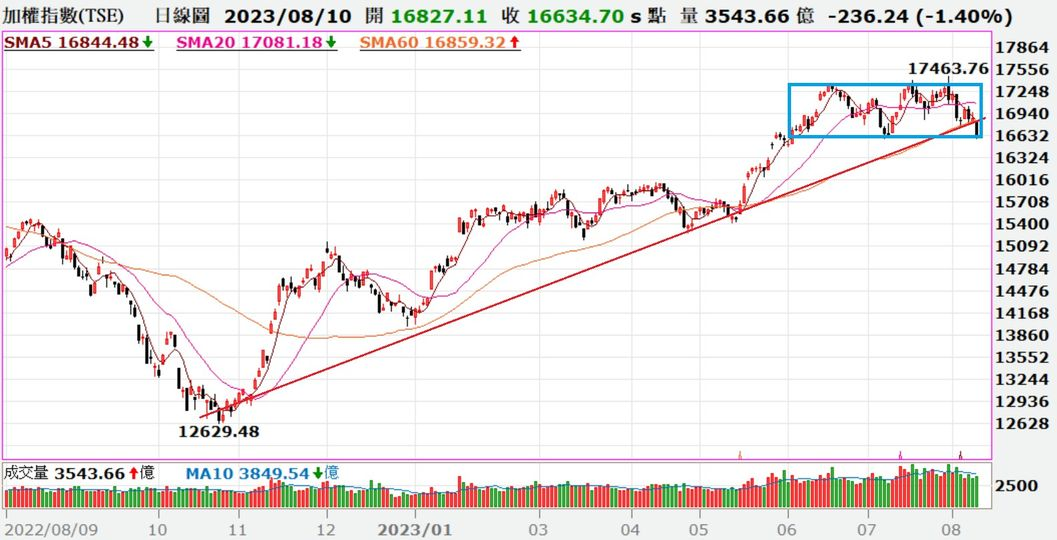

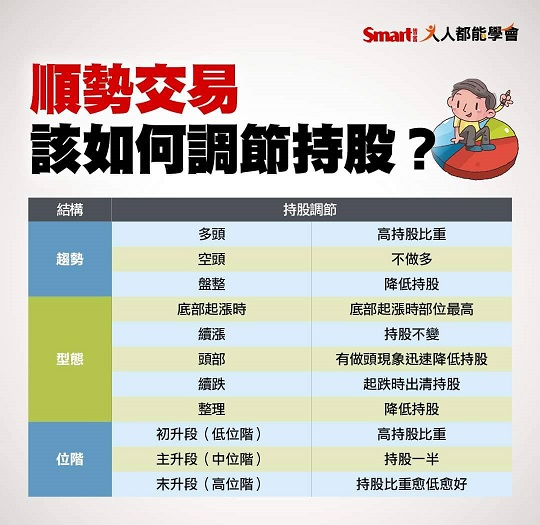  
  
[上市櫃7月營收 三年同期新低](https://readers.ctee.com.tw/cm/20230811/a01aa1/1253207/share)  
  
[融資浮額大減55億元](https://readers.ctee.com.tw/cm/20230811/a02aa2/1253213/share)  
  
[投信、公股行庫 左右護盤](https://readers.ctee.com.tw/cm/20230811/a02aa2/1253216/share)  
  
[原油 供油端利多發酵 再創波段新高](https://readers.ctee.com.tw/cm/20230811/a09aa9/1253251/share)  
  
[MSCI 季度調整 全球標準指數成分股新增技嘉、刪除穩懋](https://money.udn.com/money/story/5607/7361979)  

保守滿足區到了，樂觀的滿足區還差一些，可以開始執行4套劇本，看看你是哪一種囉：  
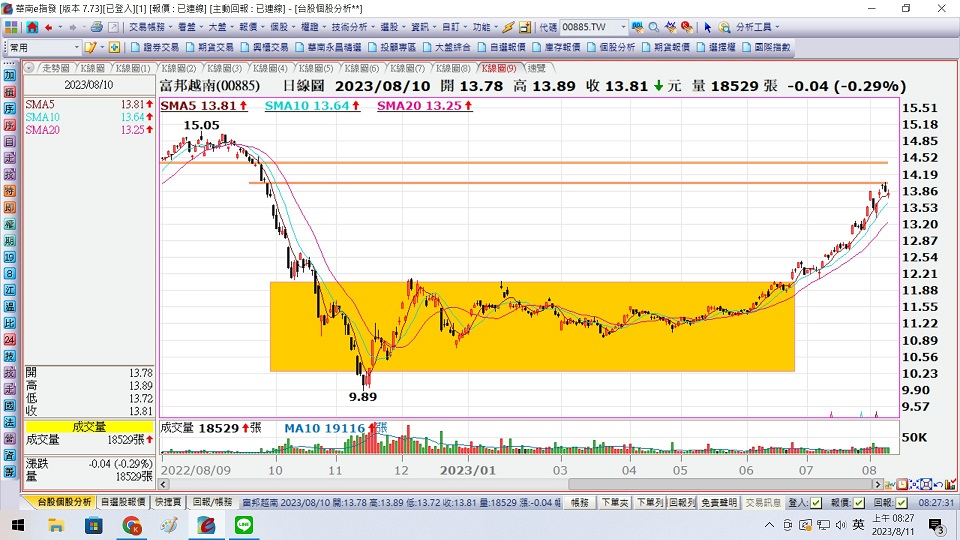  
  
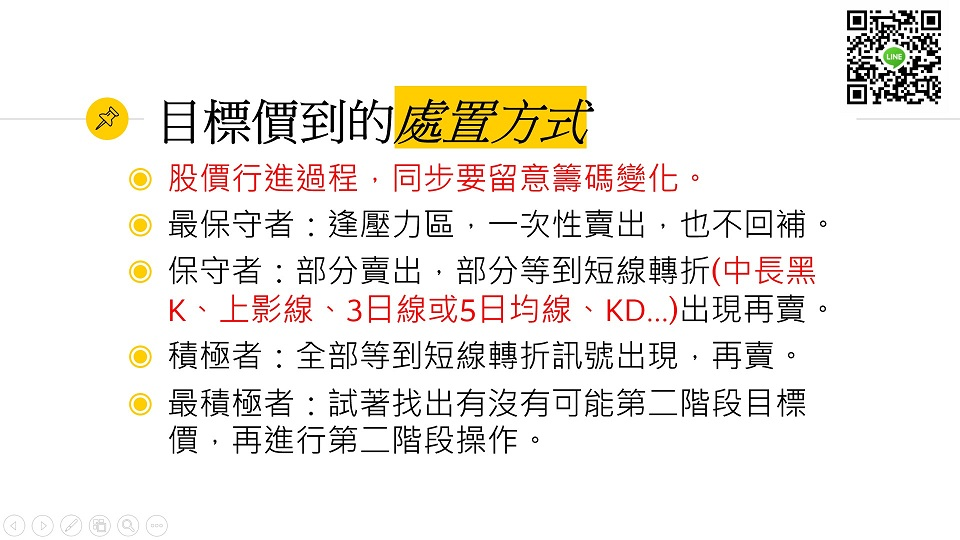  

### 本日進度  
* **暫時空手**，觀察後續盤勢發展。  
* 驗證：尋找頭肩型態([Automated Head and Shoulders Chart Pattern in Python](https://www.youtube.com/watch?v=6iFqjd5BOHw))  

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import mplfinance as mpf
import numpy as np

In [2]:
##### 尋找「頭肩底」型態函式 #####
def FindingHeadShouldersBottom(turning_points):    
    # To store pattern instances
    patterns = []
    
    # Loop to iterate along the price data
    for i in range(5, len(turning_points)):
        
        # Store 5 local minima and local maxima points at a time in the variable 'window'
        window = turning_points.iloc[i-5:i]
        
        # Ensure that pattern is formed within 120 bars
        if window.index[-1] - window.index[0] > 100:
            continue   
        
        # Store the 5 unique points to check for conditions
        a, b, c, d, e = window.iloc[0:5]['Price']
        a_type, b_type, c_type, d_type, e_type = window.iloc[0:5]['Type']
        
        # cond_1: To check a,c,e type are 'LO'
        cond_1 = (a_type == 'LO') and (c_type == 'LO') and (e_type == 'LO')
        
        # cond_2: To check b,d type are 'HI'
        cond_2 = (b_type == 'HI') and (d_type == 'HI')

        # cond_3: To check if the shoulders are above the neckline and the head is above the shoulders
        cond_3 = (a < b) and (c < a) and  (c < e) and  (c < d) and (e < d)

        # cond_4: To check if B and D are at a distance less than 5% away from their mean
        cond_4 = abs(b-d)<=np.mean([b,d])*0.05
            
        # Checking if all conditions are true
        if cond_1 and cond_2 and cond_3 and cond_4:
            patterns.append(window)
    
    return patterns

範例：台燿(6274)

In [3]:
##### 使用2022年2月25日到2023年4月7日之日線圖資料 #####

# 載入從「好神通PLUS」輸出的Excel檔
df = pd.read_excel('./data/SINO_6274_230407.xlsx')

# 保存K棒的基本資訊(開、高、低、收、量)
df_k_line = df.drop(columns=['SMA5','SMA10','SMA20','SMA60','SMA120','SMA240','MA5','MA10'])

# 保存價的均線
df_sma = df.drop(columns=['開盤價','最高價','最低價','收盤價','成交量','MA5','MA10']) 

# 將K棒的Columns的名稱由中文改為英文
df_k_line = df_k_line.rename(columns={'時間':'Date','開盤價':'Open','最高價':'High','最低價':'Low','收盤價':'Close','成交量':'Volume'})

# 將價的均線的Columns的名稱由中文改為英文
df_sma = df_sma.rename(columns={'時間':'Date'})

# 將K棒的Date設為Index
df_k_line.set_index(df_k_line['Date'],inplace=True)
df_k_line = df_k_line.drop(columns=['Date'])

# 將價的均線的Date設為Index
df_sma.set_index(df_sma['Date'],inplace=True)
df_sma = df_sma.drop(columns=['Date'])

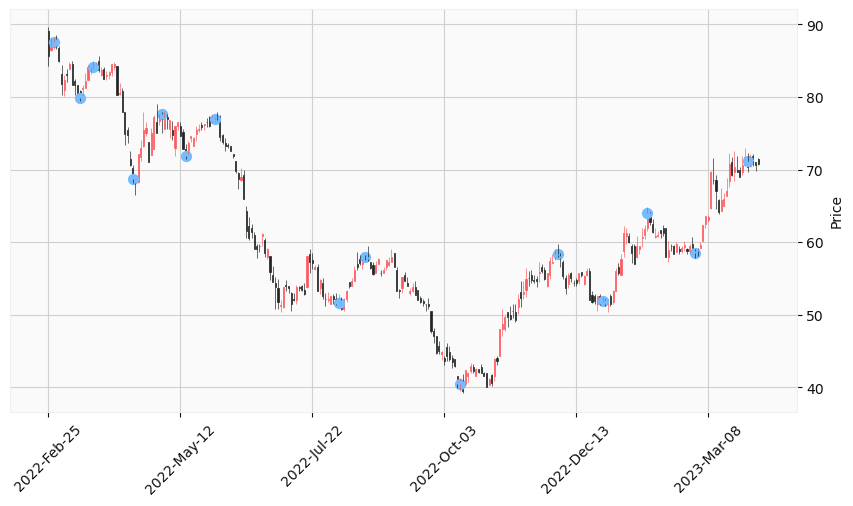

In [4]:
import myutils

# 尋找轉折點
_,_,max_min = myutils.FindingTurningPoints(df_k_line,'close',order=10,smoothing=3,real_body=True)

# 設定K線格式
mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

# 設定均線與轉折點    
turning_points_len = len(np.array(df_k_line['Close']))
turning_points = np.array([np.nan]*turning_points_len)
for point in max_min.iterrows() :
    turning_points[point[0]] = point[1]['Price']    
apds = [
    mpf.make_addplot(turning_points,type='scatter',marker='o',markersize=50,color='xkcd:sky blue')
]

# 繪出K線圖
kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=apds)
mpf.plot(df_k_line,**kwargs)

找到一個型態：


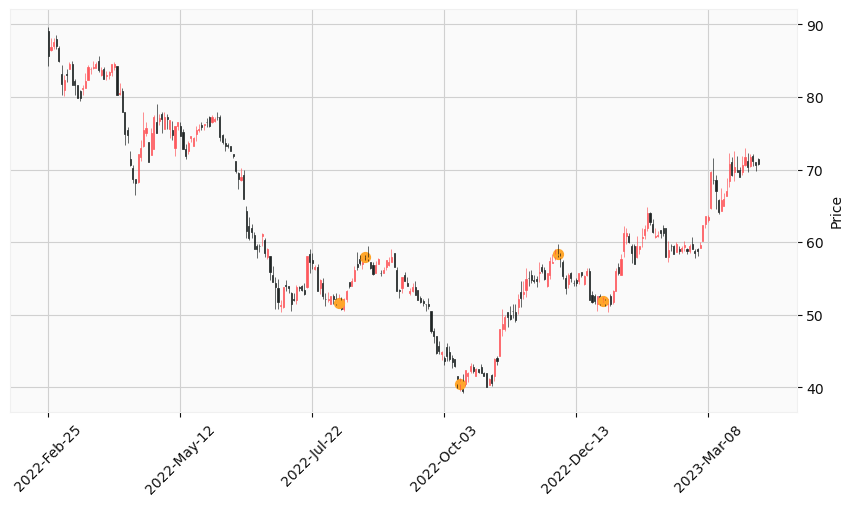

In [5]:
patterns_points_len = len(np.array(df_k_line['Close']))
patterns_points = np.array([np.nan]*patterns_points_len)
# 尋找「頭肩底」型態
patterns = FindingHeadShouldersBottom(max_min)
if len(patterns) > 0 :
    for pattern in patterns :
        print('找到一個型態：')
        for point in pattern.iterrows():
            # 標記型態的5個連續點
            patterns_points[point[0]] = point[1]['Price']
        apds = [
            mpf.make_addplot(patterns_points,type='scatter',marker='o',markersize=50,color='xkcd:mango')
        ]
        # 繪出K線圖
        kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=apds)
        mpf.plot(df_k_line,**kwargs)
else :
    print('沒有找到型態')

[{'type': 'Bottom', 'points': [[111, '2022-08-08', 50.8], [130, '2022-09-02', 58.0], [157, '2022-10-13', 39.4], [192, '2022-12-01', 58.4], [209, '2022-12-26', 51.4]], 'neckline': {'start_date': '2022-07-20', 'start_price': 57.79354838709678, 'end_date': '2023-01-09', 'end_price': 58.567741935483866}, 'head': {'width': 62, 'height': 18.774193548387096}}]
目標價＝頭部高度（18.77）＋頸線結束價格（58.57）＝77.34


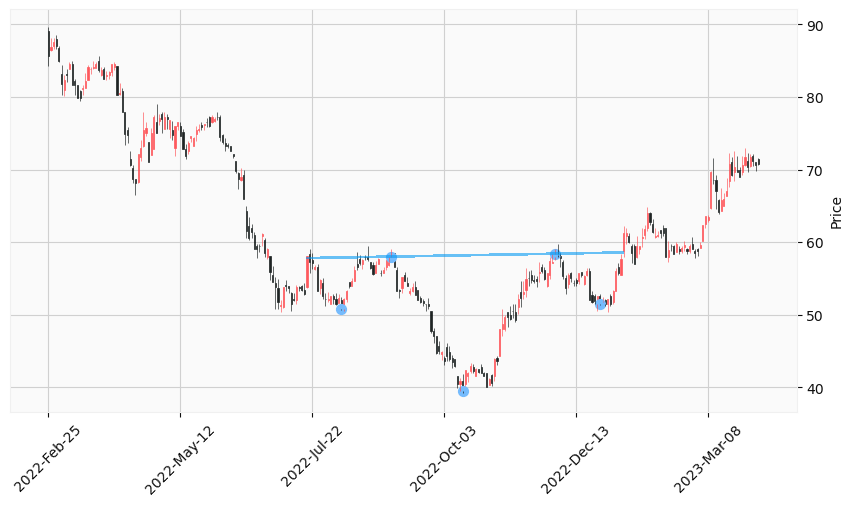

In [6]:
patterns = myutils.FindingHeadShoulderPatterns(df_k_line, 10)
print(patterns)

for pattern in patterns :
    pattern_points_len = len(np.array(df_k_line['Close']))
    pattern_points = np.array([np.nan]*pattern_points_len)
    head_shoulder_points = pattern['points']
    pattern_points[head_shoulder_points[0][0]] = head_shoulder_points[0][2]
    pattern_points[head_shoulder_points[1][0]] = head_shoulder_points[1][2]
    pattern_points[head_shoulder_points[2][0]] = head_shoulder_points[2][2]
    pattern_points[head_shoulder_points[3][0]] = head_shoulder_points[3][2]
    pattern_points[head_shoulder_points[4][0]] = head_shoulder_points[4][2]
    head_shoulder_neckline = pattern['neckline']
    head_shoulder_head     = pattern['head']
    # 試算目標價
    target_price = head_shoulder_head['height'] + head_shoulder_neckline['end_price']
    print('目標價＝頭部高度（{:.2f}）＋頸線結束價格（{:.2f}）＝{:.2f}'.format(head_shoulder_head['height'],head_shoulder_neckline['end_price'],target_price))
    # 設定K線格式
    mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
    s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)
    # 設定頸線
    seq_of_seq_of_points=[
        [(head_shoulder_neckline['start_date'],head_shoulder_neckline['start_price']),(head_shoulder_neckline['end_date'],head_shoulder_neckline['end_price'])]
    ]
    # 設定轉折點
    apds = [
        mpf.make_addplot(pattern_points,type='scatter',marker='o',markersize=50,color='xkcd:sky blue')
    ]
    # 繪出K線圖
    kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=apds,alines=dict(alines=seq_of_seq_of_points, linewidths=1.2, colors='xkcd:azure', alpha=0.6))
    mpf.plot(df_k_line,**kwargs)

範例：期街口布蘭特正2(00715L)

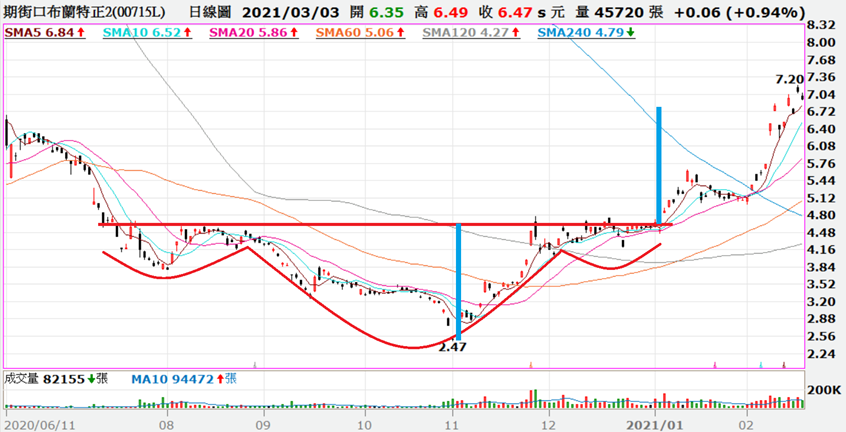

In [7]:
##### 使用2020年6月11日到2021年3月3日之日線圖資料 #####

# 載入從「好神通PLUS」輸出的Excel檔
df = pd.read_excel('./data/SINO_00715L_230811.xlsx')

# 保存K棒的基本資訊(開、高、低、收、量)
df_k_line = df.drop(columns=['SMA5','SMA10','SMA20','SMA60','SMA120','SMA240','MA5','MA10'])

# 保存價的均線
df_sma = df.drop(columns=['開盤價','最高價','最低價','收盤價','成交量','MA5','MA10']) 

# 將K棒的Columns的名稱由中文改為英文
df_k_line = df_k_line.rename(columns={'時間':'Date','開盤價':'Open','最高價':'High','最低價':'Low','收盤價':'Close','成交量':'Volume'})

# 將價的均線的Columns的名稱由中文改為英文
df_sma = df_sma.rename(columns={'時間':'Date'})

# 將K棒的Date設為Index
df_k_line.set_index(df_k_line['Date'],inplace=True)
df_k_line = df_k_line.drop(columns=['Date'])

# 將價的均線的Date設為Index
df_sma.set_index(df_sma['Date'],inplace=True)
df_sma = df_sma.drop(columns=['Date'])

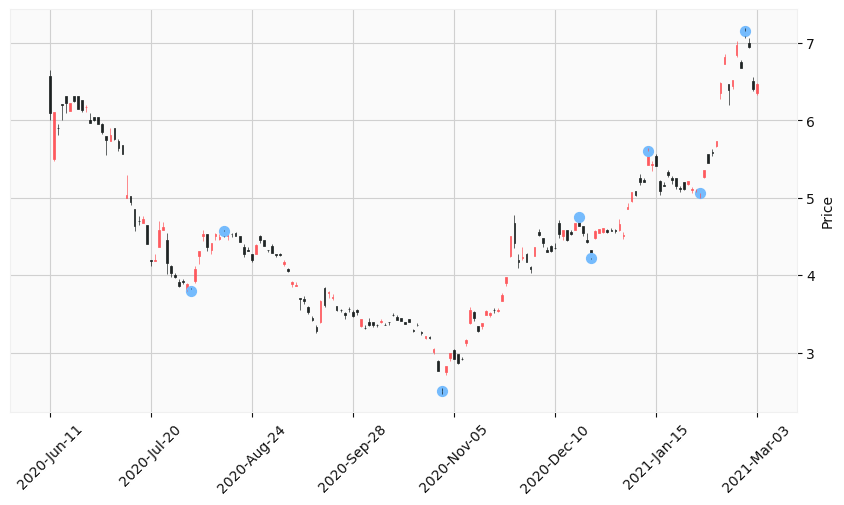

In [8]:
# 尋找轉折點
_,_,max_min = myutils.FindingTurningPoints(df_k_line,'open_close',order=10)

# 設定K線格式
mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

# 設定均線與轉折點    
turning_points_len = len(np.array(df_k_line['Close']))
turning_points = np.array([np.nan]*turning_points_len)
for point in max_min.iterrows() :
    turning_points[point[0]] = point[1]['Price']    
apds = [
    mpf.make_addplot(turning_points,type='scatter',marker='o',markersize=50,color='xkcd:sky blue')
]

# 繪出K線圖
kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=apds)
mpf.plot(df_k_line,**kwargs)

找到一個型態：


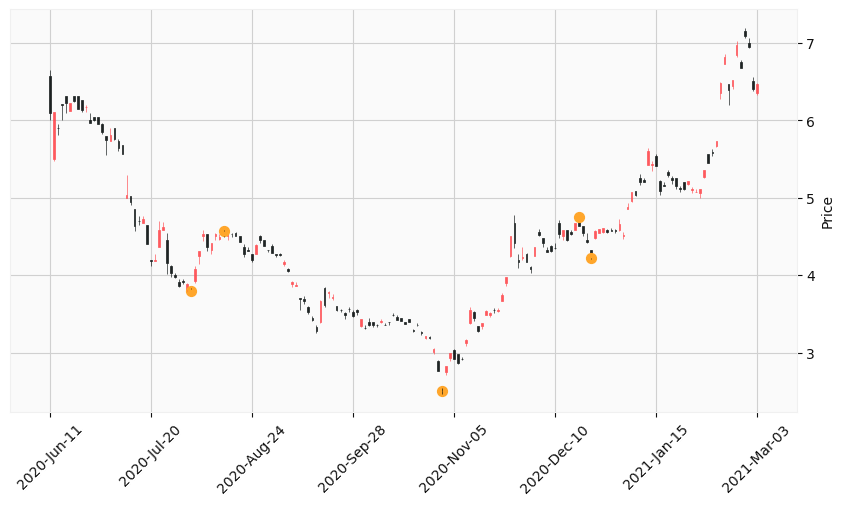

In [9]:
patterns_points_len = len(np.array(df_k_line['Close']))
patterns_points = np.array([np.nan]*patterns_points_len)
# 尋找「頭肩底」型態
patterns = FindingHeadShouldersBottom(max_min)
if len(patterns) > 0 :
    for pattern in patterns :
        print('找到一個型態：')
        for point in pattern.iterrows():
            # 標記型態的5個連續點
            patterns_points[point[0]] = point[1]['Price']
        apds = [
            mpf.make_addplot(patterns_points,type='scatter',marker='o',markersize=50,color='xkcd:mango')
        ]
        # 繪出K線圖
        kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=apds)
        mpf.plot(df_k_line,**kwargs)
else :
    print('沒有找到型態')

[{'type': 'Bottom', 'points': [[78, '2020-10-05', 3.32], [85, '2020-10-15', 3.49], [97, '2020-11-02', 2.5], [104, '2020-11-11', 3.55], [106, '2020-11-13', 3.28]], 'neckline': {'start_date': '2020-09-29', 'start_price': 3.4615789473684213, 'end_date': '2020-11-23', 'end_price': 3.5752631578947365}, 'head': {'width': 19, 'height': 1.0278947368421054}}]
目標價＝頭部高度（1.03）＋頸線結束價格（3.58）＝4.60


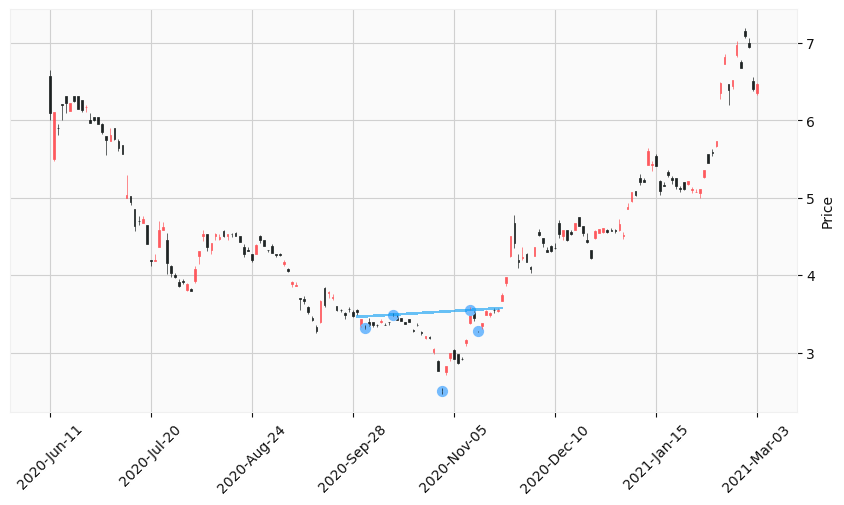

In [10]:
patterns = myutils.FindingHeadShoulderPatterns(df_k_line, 5)
print(patterns)

for pattern in patterns :
    pattern_points_len = len(np.array(df_k_line['Close']))
    pattern_points = np.array([np.nan]*pattern_points_len)
    head_shoulder_points = pattern['points']
    pattern_points[head_shoulder_points[0][0]] = head_shoulder_points[0][2]
    pattern_points[head_shoulder_points[1][0]] = head_shoulder_points[1][2]
    pattern_points[head_shoulder_points[2][0]] = head_shoulder_points[2][2]
    pattern_points[head_shoulder_points[3][0]] = head_shoulder_points[3][2]
    pattern_points[head_shoulder_points[4][0]] = head_shoulder_points[4][2]
    head_shoulder_neckline = pattern['neckline']
    head_shoulder_head     = pattern['head']
    # 試算目標價
    target_price = head_shoulder_head['height'] + head_shoulder_neckline['end_price']
    print('目標價＝頭部高度（{:.2f}）＋頸線結束價格（{:.2f}）＝{:.2f}'.format(head_shoulder_head['height'],head_shoulder_neckline['end_price'],target_price))
    # 設定K線格式
    mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
    s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)
    # 設定頸線
    seq_of_seq_of_points=[
        [(head_shoulder_neckline['start_date'],head_shoulder_neckline['start_price']),(head_shoulder_neckline['end_date'],head_shoulder_neckline['end_price'])]
    ]
    # 設定轉折點
    apds = [
        mpf.make_addplot(pattern_points,type='scatter',marker='o',markersize=50,color='xkcd:sky blue')
    ]
    # 繪出K線圖
    kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=apds,alines=dict(alines=seq_of_seq_of_points, linewidths=1.2, colors='xkcd:azure', alpha=0.6))
    mpf.plot(df_k_line,**kwargs)

* 進行整合先前完成的程式碼(轉折點、頭肩底型態與趨勢線…等)與[neurotrader](https://www.youtube.com/@neurotrader888/videos)之程式碼：  
  - 位階  
    + [量化位階評價法](https://vocus.cc/article/62ada936fd89780001fe6208) ： 完成 **StockRankEvaluate** 類別 \[已整合進**myutils套件**\]
  - 轉折點  
    + 峰位∕谷底的演變程序([peak-and-trough progression](https://www.amazon.com/Technical-Analysis-Explained-Fifth-Successful/dp/0071825177)) 與 滾動窗口([Rolling Window](https://www.youtube.com/watch?v=X31hyMhB-3s&t=49s)) ： 已完成 **FindingTurningPoints()** 函式 \[已整合進**myutils套件**\]
    + 方向變化([Directional Change](https://www.youtube.com/watch?v=X31hyMhB-3s&t=179s)) ： [directional_change.py](https://github.com/neurotrader888/TechnicalAnalysisAutomation/blob/main/directional_change.py) 已完成 **FindingDirectionalChangePoints()** 函式 \[已整合進**myutils套件**\]  
    + 感知重要點([Perceptually Important Points](https://www.youtube.com/watch?v=X31hyMhB-3s&t=339s)) ： [perceptually_important.py](https://tinyurl.com/yc2bykhr) 已完成**FindingPerceptuallyImportantPoints()** 函式 \[已整合進**myutils套件**\]  
  - 趨勢線  
    + ~~自行開發 ： 模擬手工方式，由兩個轉折點中畫出一條趨勢線~~ - **效果不佳，暫緩進行**  
    + 自動價格趨勢線([Automated Price Trend Lines](https://www.youtube.com/watch?v=wbFoefnidTU)) ： [trendline_automation.py](https://github.com/neurotrader888/TechnicalAnalysisAutomation/blob/main/trendline_automation.py)  已完成**FitTrendlines()**函式 \[已整合進**myutils套件**\]  
  - 型態  
    + 頭肩底(或 頭肩頂)演算法一([Algorithmically Detecting (and Trading) Technical Chart Patterns with Python](https://medium.com/automation-generation/algorithmically-detecting-and-trading-technical-chart-patterns-with-python-c577b3a396ed)) ： [tech_screener_notebook.ipynb](https://github.com/samchaaa/alpaca_tech_screener/blob/master/tech_screener_notebook.ipynb) ：  **FindingHeadShouldersBottom()** 函式已完成，但不會整合進myutils套件中 
    + 頭肩底(或 頭肩頂)演算法二([Automated Head and Shoulders Chart Pattern in Python](https://www.youtube.com/watch?v=6iFqjd5BOHw)) ： [head_shoulders.py](https://github.com/neurotrader888/TechnicalAnalysisAutomation/blob/main/head_shoulders.py) 已完成**FindingHeadShoulderPatterns()** 函式 \[已整合進**myutils套件**\]  
    + ~~旗型與三角旗型演算法([Flag and Pennant Pattern Recognition](https://www.youtube.com/watch?v=Lb5SPCTp4uY)) ： [flags_pennants.py](https://github.com/neurotrader888/TechnicalAnalysisAutomation/blob/main/flags_pennants.py)~~ - **演算法不確定，暫緩進行**  

### 史塔克財金工作室 進階班  
* 重要訊息:今天周五晚上課程，順延至下週五，大家也順便放個假，複習一下之前的課程。